In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N_IND   = 5
L_IND   = 20
PC      = 0.70
PM      = 1/15
MAX_GEN = 100
N_VAR   = 1
RANGO   = np.array([[0.0],
                    [0.875]])
 
np.random.seed(7)

In [4]:
def crear_poblacion(n, l):
    return np.random.randint(0, 2, size=(n, l))
 
 
def decodificar(cromosomas, rango):
    """Convierte cromosomas binarios a valores reales en el dominio dado."""
    n, l  = cromosomas.shape
    pesos = 2 ** np.arange(l)
    vals  = cromosomas @ pesos
    lo, hi = rango[0, 0], rango[1, 0]
    real  = lo + (hi - lo) / (2**l - 1) * vals
    return real.reshape(-1, 1)

def evaluar(fenotipos):
    """Evalúa f(x) = (1 - t²)·cos(t) + 3  donde t = (11/2)(x - 7/2)."""
    x = fenotipos[:, 0]
    t = (11/2) * (x - 7/2)
    return ((1 - t**2) * np.cos(t) + 1 + 2).reshape(-1, 1)
 
 
def calcular_aptitud(obj_vals):
    """Rankeo lineal para garantizar aptitudes positivas."""
    SP   = 2
    n    = obj_vals.shape[0]
    apt  = np.zeros((n, 1))
    vals = 2 - SP + 2*(SP-1) * (np.arange(n) / (n-1))
    pos  = np.argsort(obj_vals[:, 0])
    apt[pos, 0] = vals
    return apt
 
 
def seleccion_ruleta(cromosomas, aptitud):
    n     = aptitud.shape[0]
    prob  = (aptitud / aptitud.sum()).cumsum()
    idx   = [np.where(prob >= np.random.rand())[0][0] for _ in range(n)]
    return cromosomas[idx, :]
 
 
def cruza_un_punto(pop, pc):
    n, l  = pop.shape
    nueva = np.zeros_like(pop)
    par   = n % 2
 
    for i in range(0, n - 1, 2):
        if np.random.rand() < pc:
            c           = np.random.randint(1, l - 1)
            nueva[i]    = np.concatenate([pop[i, :c],   pop[i+1, c:]])
            nueva[i+1]  = np.concatenate([pop[i+1, :c], pop[i,   c:]])
        else:
            nueva[i]    = pop[i]
            nueva[i+1]  = pop[i+1]
 
    if par == 1:
        nueva[-1] = pop[-1]
    return nueva
 
 
def mutar(pop, pm):
    mascara = np.random.rand(*pop.shape) <= pm
    return np.logical_xor(pop, mascara).astype(int)


In [5]:
cromosomas = crear_poblacion(N_IND, L_IND)
fenotipos  = decodificar(cromosomas, RANGO)
obj_vals   = evaluar(fenotipos)
 
historial_mejor = np.full(MAX_GEN, np.nan)
historial_avg   = np.full(MAX_GEN, np.nan)
 
for gen in range(MAX_GEN):
    historial_mejor[gen] = obj_vals.max()
    historial_avg[gen]   = obj_vals.mean()
 
    aptitud    = calcular_aptitud(obj_vals)
    cromosomas = seleccion_ruleta(cromosomas, aptitud)
    cromosomas = cruza_un_punto(cromosomas, PC)
    cromosomas = mutar(cromosomas, PM)
    fenotipos  = decodificar(cromosomas, RANGO)
    obj_vals   = evaluar(fenotipos)
 
idx_mejor  = np.argmax(obj_vals)
mejor_x    = fenotipos[idx_mejor, 0]
mejor_val  = obj_vals[idx_mejor, 0]
 
print(f"\nMejor valor encontrado : f(x) = {mejor_val:.6f}")
print(f"En x = {mejor_x:.6f}")



Mejor valor encontrado : f(x) = 245.780942
En x = 0.657364


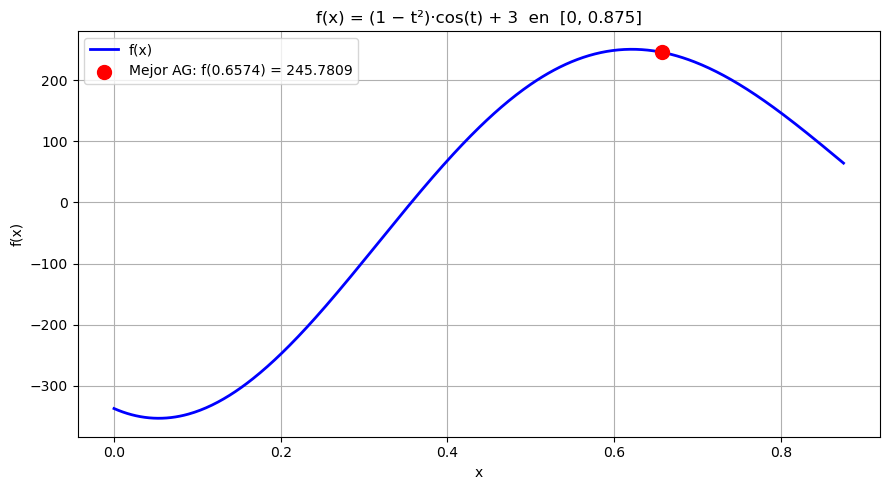

In [6]:
x_plot = np.linspace(0, 0.875, 500)
t_plot = (11/2) * (x_plot - 7/2)
y_plot = (1 - t_plot**2) * np.cos(t_plot) + 3
 
plt.figure(figsize=(9, 5))
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
plt.scatter(mejor_x, mejor_val, color='red', s=100, zorder=5,
            label=f'Mejor AG: f({mejor_x:.4f}) = {mejor_val:.4f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('f(x) = (1 − t²)·cos(t) + 3  en  [0, 0.875]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
